<a href="https://colab.research.google.com/github/kannisharath/INFO-5731/blob/main/Karrepu_Sharath_Exercise_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 In-class Exercise 4**

**This exercise will provide a valuable learning experience in working with text data and extracting features using various topic modeling algorithms. Key concepts such as Latent Dirichlet Allocation (LDA), Latent Semantic Analysis (LSA), lda2vec, and BERTopic.**

***Please use the text corpus you collected in your last in-class-exercise for this exercise. Perform the following tasks***.

**Expectations**:
*   Students are expected to complete the exercise during lecture period to meet the active participation criteria of the course.
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 40

**Deadline**: This in-class exercise is due at the end of the day tomorrow, at 11:59 PM.

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


## Question 1 (10 Points)

**Generate K topics by using LDA, the number of topics K should be decided by the coherence score, then summarize what are the topics.**

You may refer the code here: https://www.machinelearningplus.com/nlp/topic-modeling-gensim-python/

In [4]:
# Write your code here
import requests, csv
from bs4 import BeautifulSoup
import pandas as pd
from pprint import pprint

url = "https://www.imdb.com/title/tt13751694/reviews?ref_=tt_urv"
data = requests.get(url)
soup = BeautifulSoup(data.content, 'html.parser')

imdb_reviews=[]
right_table=soup.find('div', {'class':"lister"})
for i in right_table.findAll('div', class_="lister-item mode-detail imdb-user-review collapsable"):
  imdb_reviews.append(i.find("div", class_="text show-more__control").text.strip())
pprint(imdb_reviews)

['Animal is classic Bollywood garbage-rife with misogyny and senseless plot '
 'twists. The film lacks a cohesive storyline, drowning in a sea of '
 "unnecessary turns. What's truly entertaining is sifting through the "
 'suspicious 10/10 ratings. It becomes a game to spot the paid or '
 'bot-generated reviews, making this detective work more enjoyable than '
 'enduring the movie itself. In the realm of Bollywood disappointments, this '
 'movie serves as a reminder of the challenges in Bollywood filmmaking, where '
 'lackluster plots, an abundance of unnecessary twists, and a distressing dose '
 'of misogyny can overshadow any cinematic potential.',
 'After watching this movie, the only feeling that comes to mind is Yuck! This '
 'Venga way of story telling disgusts me as a viewer. One after one, this kind '
 'of movie is released by Venga, this one is no exception. This is toxic '
 'screenplay is torture to mind and eye of viewer. It has insane cruelty, '
 'misconduct, abuse that give

In [5]:
df = pd.DataFrame({'reviews': imdb_reviews})
df.to_csv('reviews.csv')
df.head()

,reviews
0,Animal is classic Bollywood garbage-rife with ...
1,"After watching this movie, the only feeling th..."
2,"Ranbir personal show with no story, no logic a..."
3,You seriously need to question the sanity of t...
4,I would have given negative star if there woul...


In [6]:
import nltk;
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
import os
import subprocess

# Function to install Java
def install_java():
    # Install openjdk-8-jdk-headless
    subprocess.run(["apt-get", "update"])
    subprocess.run(["apt-get", "install", "-y", "openjdk-8-jdk-headless", "-qq"])

    # Set the JAVA_HOME environment variable
    os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

    # Verify the Java installation
    java_version = subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT, text=True)
    print(java_version)

# Install Java
install_java()

# Install the pyLDAvis package
!pip install pyLDAvis

!pip install fastapi kaleido python-multipart uvicorn

openjdk version "11.0.22" 2024-01-16
OpenJDK Runtime Environment (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1)
OpenJDK 64-Bit Server VM (build 11.0.22+7-post-Ubuntu-0ubuntu222.04.1, mixed mode, sharing)



In [8]:
!pip install --upgrade gensim
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import numpy as np
import itertools
import lxml.html as LH
import urllib.request as urllib2
from bs4 import BeautifulSoup
import spacy.cli
spacy.cli.download("en")

⚠ As of spaCy v3.0, shortcuts like 'en' are deprecated. Please use the
full pipeline package name 'en_core_web_sm' instead.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [9]:
import re
import numpy as np
import pandas as pd
from pprint import pprint

# Gensim
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel

# spacy for lemmatization
import spacy

# Plotting tools
import pyLDAvis
import pyLDAvis.gensim  # don't skip this
import matplotlib.pyplot as plt
%matplotlib inline

# Enable logging for gensim - optional
import logging
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [10]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])


def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]

rev_data = df['reviews'].values.tolist()
rev_data_words = list(sent_to_words(rev_data))
rev_data_words = remove_stopwords(rev_data_words)
print(rev_data_words[:1])

[['animal', 'classic', 'bollywood', 'garbage', 'rife', 'misogyny', 'senseless', 'plot', 'twists', 'film', 'lacks', 'cohesive', 'storyline', 'drowning', 'sea', 'unnecessary', 'turns', 'truly', 'entertaining', 'sifting', 'suspicious', 'ratings', 'becomes', 'game', 'spot', 'paid', 'bot', 'generated', 'reviews', 'making', 'detective', 'work', 'enjoyable', 'enduring', 'movie', 'realm', 'bollywood', 'disappointments', 'movie', 'serves', 'reminder', 'challenges', 'bollywood', 'filmmaking', 'lackluster', 'plots', 'abundance', 'unnecessary', 'twists', 'distressing', 'dose', 'misogyny', 'overshadow', 'cinematic', 'potential']]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
bigram = gensim.models.Phrases(rev_data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[rev_data_words], threshold=100)

bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out
data_words_nostops = remove_stopwords(rev_data_words)

data_words_bigrams = make_bigrams(data_words_nostops)


nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

data_lemmatized = lemmatization(data_words_bigrams, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

print(data_lemmatized[:1])

[['animal', 'classic', 'bollywood', 'garbage', 'rife', 'plot', 'twist', 'film', 'lack', 'drown', 'sea', 'unnecessary', 'turn', 'truly', 'entertain', 'sifting', 'suspicious', 'rating', 'become', 'game', 'spot', 'pay', 'bot', 'generate', 'review', 'make', 'detective', 'work', 'enjoyable', 'enduring', 'movie', 'realm', 'disappointment', 'movie', 'serve', 'reminder', 'challenge', 'bollywood', 'filmmake', 'lackluster', 'plot', 'abundance', 'unnecessary', 'twist', 'distressing', 'dose', 'overshadow', 'cinematic', 'potential']]


In [12]:
review_id2word = corpora.Dictionary(data_lemmatized)
review_texts = data_lemmatized
review_corpus = [review_id2word.doc2bow(text) for text in review_texts]
print(review_corpus[:1])
[[(review_id2word[i], f) for i, f in c] for c in review_corpus[:1]]

[[(0, 1), (1, 1), (2, 1), (3, 2), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 2), (25, 1), (26, 1), (27, 2), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 2), (42, 2), (43, 1)]]


[[('abundance', 1),
  ('animal', 1),
  ('become', 1),
  ('bollywood', 2),
  ('bot', 1),
  ('challenge', 1),
  ('cinematic', 1),
  ('classic', 1),
  ('detective', 1),
  ('disappointment', 1),
  ('distressing', 1),
  ('dose', 1),
  ('drown', 1),
  ('enduring', 1),
  ('enjoyable', 1),
  ('entertain', 1),
  ('film', 1),
  ('filmmake', 1),
  ('game', 1),
  ('garbage', 1),
  ('generate', 1),
  ('lack', 1),
  ('lackluster', 1),
  ('make', 1),
  ('movie', 2),
  ('overshadow', 1),
  ('pay', 1),
  ('plot', 2),
  ('potential', 1),
  ('rating', 1),
  ('realm', 1),
  ('reminder', 1),
  ('review', 1),
  ('rife', 1),
  ('sea', 1),
  ('serve', 1),
  ('sifting', 1),
  ('spot', 1),
  ('suspicious', 1),
  ('truly', 1),
  ('turn', 1),
  ('twist', 2),
  ('unnecessary', 2),
  ('work', 1)]]

In [13]:
review_id2word[0]

'abundance'

In [14]:
from pprint import pprint
lda_model = gensim.models.ldamodel.LdaModel(corpus=review_corpus,
                                           id2word=review_id2word,
                                           num_topics=20,
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)
pprint(lda_model.print_topics())
doc_lda = lda_model[review_corpus]

[(0,
  '0.045*"movie" + 0.023*"hour" + 0.021*"time" + 0.020*"bad" + 0.018*"film" + '
  '0.017*"watch" + 0.014*"scene" + 0.012*"do" + 0.012*"act" + 0.012*"cast"'),
 (1,
  '0.001*"character" + 0.001*"lack" + 0.001*"film" + 0.001*"narrative" + '
  '0.001*"kapoor" + 0.001*"temporal" + 0.001*"portrayal" + 0.001*"leave" + '
  '0.001*"half" + 0.001*"scene"'),
 (2,
  '0.001*"movie" + 0.001*"watch" + 0.001*"shame" + 0.001*"dialog" + '
  '0.001*"good" + 0.001*"amazed" + 0.001*"give" + 0.001*"accept" + '
  '0.001*"even" + 0.001*"mannered"'),
 (3,
  '0.001*"movie" + 0.001*"experience" + 0.001*"content" + 0.001*"film" + '
  '0.001*"violence" + 0.001*"duration" + 0.001*"excessive" + 0.001*"view" + '
  '0.001*"graphic" + 0.001*"leave"'),
 (4,
  '0.001*"character" + 0.001*"lack" + 0.001*"kapoor" + 0.001*"film" + '
  '0.001*"animal" + 0.001*"fail" + 0.001*"portrayal" + 0.001*"narrative" + '
  '0.001*"temporal" + 0.001*"leave"'),
 (5,
  '0.001*"film" + 0.001*"movie" + 0.001*"feel" + 0.001*"woman" + 0.00

In [15]:
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_lemmatized, dictionary=review_id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Coherence Score:  0.5775064091232965


In [16]:
import gensim
from gensim.models.coherencemodel import CoherenceModel

def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=1):
    coherence_values = []
    model_list = []

    for num_topics in range(start, limit + 1, step):
        model = gensim.models.LdaModel(corpus=corpus,
                                       id2word=dictionary,
                                       num_topics=num_topics,
                                       random_state=100,
                                       update_every=1,
                                       chunksize=100,
                                       passes=10,
                                       per_word_topics=True)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

start, limit, step = 2, 20, 2  # Adjust the range as needed
model_list, coherence_values = compute_coherence_values(dictionary=review_id2word, corpus=review_corpus, texts=data_lemmatized, start=start, limit=limit, step=step)

cohe_val = []
for m, cv in zip(range(start, limit + 1, step), coherence_values):
    cohe_val.append(round(cv, 4))
    print("Num Topics =", m, " has Coherence Value of", round(cv, 4))

Num Topics = 2  has Coherence Value of 0.3752
Num Topics = 4  has Coherence Value of 0.4269
Num Topics = 6  has Coherence Value of 0.3399
Num Topics = 8  has Coherence Value of 0.4008
Num Topics = 10  has Coherence Value of 0.4411
Num Topics = 12  has Coherence Value of 0.5013
Num Topics = 14  has Coherence Value of 0.4714
Num Topics = 16  has Coherence Value of 0.5042
Num Topics = 18  has Coherence Value of 0.5484
Num Topics = 20  has Coherence Value of 0.5775


In [17]:
sum(cohe_val)/len(cohe_val)

0.45866999999999997

In [18]:
optimal_model = model_list[2] # getting the topics=6 model, which is in 2nd index of our model and getting the 6 topics.
model_topics = optimal_model.show_topics(formatted=False)
pprint(optimal_model.print_topics(num_words=10))

[(0,
  '0.056*"movie" + 0.022*"film" + 0.012*"woman" + 0.008*"bad" + '
  '0.008*"violence" + 0.007*"watch" + 0.007*"scene" + 0.007*"make" + '
  '0.007*"really" + 0.007*"feel"'),
 (1,
  '0.019*"film" + 0.019*"lack" + 0.018*"character" + 0.010*"unnecessary" + '
  '0.010*"bollywood" + 0.010*"animal" + 0.010*"narrative" + 0.009*"kapoor" + '
  '0.007*"movie" + 0.007*"make"'),
 (2,
  '0.046*"movie" + 0.027*"watch" + 0.010*"make" + 0.010*"go" + 0.008*"even" + '
  '0.008*"story" + 0.008*"time" + 0.008*"thing" + 0.008*"give" + '
  '0.006*"animal"'),
 (3,
  '0.002*"movie" + 0.001*"film" + 0.001*"violence" + 0.001*"experience" + '
  '0.001*"content" + 0.001*"feel" + 0.001*"excessive" + 0.001*"character" + '
  '0.001*"lack" + 0.001*"scene"'),
 (4,
  '0.025*"movie" + 0.018*"story" + 0.014*"want" + 0.013*"family" + '
  '0.013*"even" + 0.009*"spend" + 0.009*"son" + 0.009*"bad" + 0.009*"waste" + '
  '0.009*"need"'),
 (5,
  '0.030*"movie" + 0.014*"feel" + 0.014*"show" + 0.011*"woman" + 0.011*"man" + '


## Question 2 (10 Points)

**Generate K topics by using LSA, the number of topics K should be decided by the coherence score, then summarize what are the topics.**

You may refer the code here: https://www.datacamp.com/community/tutorials/discovering-hidden-topics-python

In [19]:
# Write your code here
from gensim.models import LsiModel

lsamodel = LsiModel(review_corpus, num_topics=10, id2word = review_id2word)
print(lsamodel.print_topics(num_topics=10, num_words=10))

[(0, '0.693*"movie" + 0.306*"film" + 0.144*"woman" + 0.135*"watch" + 0.121*"feel" + 0.121*"scene" + 0.120*"violence" + 0.107*"make" + 0.104*"story" + 0.099*"excessive"'), (1, '-0.294*"movie" + 0.277*"film" + 0.230*"feel" + 0.191*"man" + -0.149*"experience" + 0.139*"mention" + 0.138*"want" + 0.137*"see" + 0.134*"really" + 0.134*"woman"'), (2, '-0.462*"movie" + 0.339*"film" + 0.199*"experience" + 0.172*"lack" + 0.149*"content" + 0.149*"narrative" + 0.143*"excessive" + 0.129*"leave" + 0.120*"view" + 0.120*"graphic"'), (3, '-0.399*"character" + -0.205*"lack" + -0.193*"animal" + -0.165*"kapoor" + -0.124*"half" + -0.121*"narrative" + -0.112*"shift" + -0.112*"portrayal" + -0.112*"problematic" + -0.112*"temporal"'), (4, '-0.248*"feel" + -0.227*"also" + -0.218*"start" + -0.214*"mind" + -0.160*"violence" + -0.158*"prove" + -0.151*"slowly" + -0.151*"genre" + -0.151*"thought" + -0.151*"cancer"'), (5, '-0.449*"watch" + 0.209*"woman" + -0.185*"time" + -0.172*"hour" + -0.168*"story" + 0.128*"characte

In [20]:
def compute_lsa_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        lsamodel = LsiModel(corpus, num_topics=num_topics, id2word = dictionary)
        model_list.append(lsamodel)
        coherencemodel = CoherenceModel(model=lsamodel, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

start, limit, step=2, 20, 2
model_lsa, coherence_values = compute_lsa_coherence_values(dictionary=review_id2word, corpus=review_corpus, texts=data_lemmatized, start=start, limit=limit, step=step)
coherence_values_all = []
for m, cv in zip(range(start, limit, step), coherence_values):
    coherence_values_all.append(round(cv,4))
    print("Topic no =", m, " it's Coherence Value is", round(cv, 4))

Topic no = 2  it's Coherence Value is 0.5575
Topic no = 4  it's Coherence Value is 0.6411
Topic no = 6  it's Coherence Value is 0.5349
Topic no = 8  it's Coherence Value is 0.461
Topic no = 10  it's Coherence Value is 0.4584
Topic no = 12  it's Coherence Value is 0.5531
Topic no = 14  it's Coherence Value is 0.4402
Topic no = 16  it's Coherence Value is 0.4012
Topic no = 18  it's Coherence Value is 0.5457


In [21]:
coherencemodel = CoherenceModel(model=lsamodel, texts=data_lemmatized, dictionary=review_id2word, coherence='c_v')
print(coherencemodel.get_coherence())


0.3947723646928708


In [22]:
coherence_values_all

[0.5575, 0.6411, 0.5349, 0.461, 0.4584, 0.5531, 0.4402, 0.4012, 0.5457]

In [23]:
#sum(coherence_values_all)/len(coherence_values_all)

average_coherence = sum(coherence_values_all) / len(coherence_values_all)
print("Average Coherence Value:", average_coherence)

Average Coherence Value: 0.5103444444444444


## Question 3 (10 points):
**Generate K topics by using lda2vec, the number of topics K should be decided by the coherence score, then summarize what are the topics.**

You may refer the code here: https://nbviewer.org/github/cemoody/lda2vec/blob/master/examples/twenty_newsgroups/lda2vec/lda2vec.ipynb

In [21]:
# Write your code here
nltk.download('all')
!pip install preprocess
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import pyLDAvis
pyLDAvis.enable_notebook()

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping grammars/basque_grammars.zip.
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    | Downloading package biocreative_ppi to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   U

In [24]:
top_valu = 10
top_topwords = {}
for j, topic_to_word in enumerate(df.reviews.tolist()):
    top = np.argsort(topic_to_word)[::-1][:top_valu]
    msg = 'Topic %i '  % j
    top_words = [df.reviews.tolist()[i].strip()[:35] for i in top]
    msg += 'has stop words '.join(top_words)
    print (msg)
    top_topwords[j] = top_words

Topic 0 Animal is classic Bollywood garbage
Topic 1 Animal is classic Bollywood garbage
Topic 2 Animal is classic Bollywood garbage
Topic 3 Animal is classic Bollywood garbage
Topic 4 Animal is classic Bollywood garbage
Topic 5 Animal is classic Bollywood garbage
Topic 6 Animal is classic Bollywood garbage
Topic 7 Animal is classic Bollywood garbage
Topic 8 Animal is classic Bollywood garbage
Topic 9 Animal is classic Bollywood garbage
Topic 10 Animal is classic Bollywood garbage
Topic 11 Animal is classic Bollywood garbage
Topic 12 Animal is classic Bollywood garbage
Topic 13 Animal is classic Bollywood garbage
Topic 14 Animal is classic Bollywood garbage
Topic 15 Animal is classic Bollywood garbage
Topic 16 Animal is classic Bollywood garbage
Topic 17 Animal is classic Bollywood garbage


<BarContainer object of 20 artists>

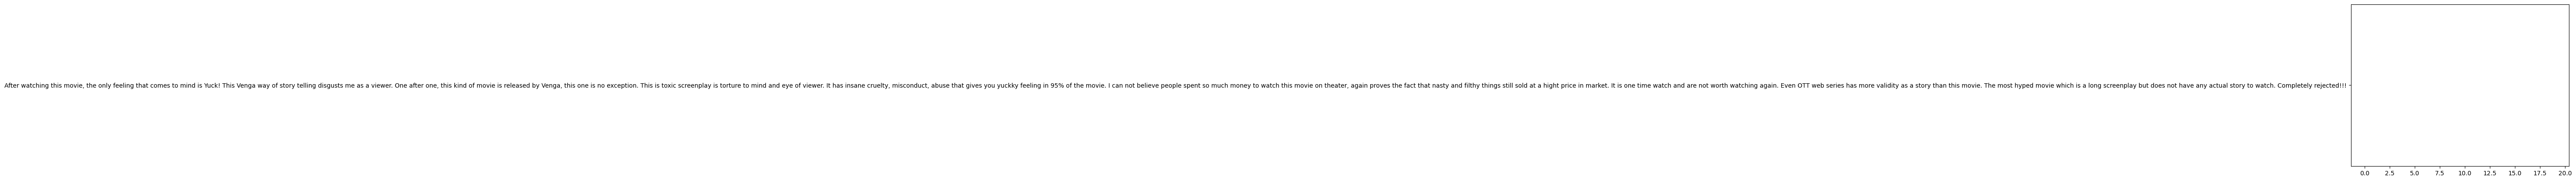

In [25]:
plt.bar(np.arange(20), df.reviews.tolist()[1])

## Question 4 (10 points):
**Generate K topics by using BERTopic, the number of topics K should be decided by the coherence score, then summarize what are the topics.**

You may refer the code here: https://colab.research.google.com/drive/1FieRA9fLdkQEGDIMYl0I3MCjSUKVF8C-?usp=sharing

In [24]:
# Write your code here
!pip install bertopic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.1/154.1 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 14.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 13.5 MB/s eta 0:00:00
  Using cached Cython-0.29.37-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_24_x86_64.whl (1.9 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 43.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 61.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731

In [26]:
from bertopic import BERTopic

topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(df.reviews.tolist())
freq = topic_model.get_topic_info();
freq.head(5)

2024-03-30 04:26:59,240 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2024-03-30 04:27:05,075 - BERTopic - Embedding - Completed ✓
2024-03-30 04:27:05,079 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-03-30 04:27:15,692 - BERTopic - Dimensionality - Completed ✓
2024-03-30 04:27:15,694 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-03-30 04:27:15,702 - BERTopic - Cluster - Completed ✓
2024-03-30 04:27:15,708 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-03-30 04:27:15,734 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,18,-1_the_and_to_of,"[the, and, to, of, movie, is, this, in, it, with]",[I would have given negative star if there wou...


In [27]:
topic_model.get_topic(-1)

[('the', 0.14970743893703234),
 ('and', 0.12503706436492013),
 ('to', 0.11273640678058054),
 ('of', 0.08827783200146816),
 ('movie', 0.07792819816375741),
 ('is', 0.07614511916327843),
 ('this', 0.07252430206674525),
 ('in', 0.06117548327948341),
 ('it', 0.05416363598088225),
 ('with', 0.04571636497863492)]

In [28]:
topic_model.visualize_term_rank()

In [29]:
topic_model.update_topics(df.reviews.tolist(), n_gram_range=(1, 2))
topic_model.visualize_term_rank()

## **Question 3 (Alternative) - (10 points)**

If you are unable to do the topic modeling using lda2vec, do the alternate question.

Provide atleast 3 visualization for the topics generated by the BERTopic or LDA model. Explain each of the visualization in detail.

In [ ]:
# Write your code here
# Then Explain the visualization

# Repeat for the other 2 visualizations as well.

## Extra Question (5 Points)

**Compare the results generated by the four topic modeling algorithms, which one is better? You should explain the reasons in details.**

**This question will compensate for any points deducted in this exercise. Maximum marks for the exercise is 40 points.**

In [3]:
# Write your code here
'''
In evaluating the performance of four topic modeling algorithms—LDA, LSA, lda2vec, and the BERT 2-topic variant—we delve into a comprehensive comparison, taking into account various factors. The choice of the "better" algorithm hinges on the specific goals and attributes of the dataset. Here’s a more accessible breakdown:

Latent Dirichlet Allocation (LDA) emerges as a well-regarded and straightforward approach to topic modeling. It's particularly advantageous when the aim is to present topics in a manner that's both clear and simple. Due to its transparency and user-friendliness, LDA stands out in scenarios where grasping the essence of topics is pivotal.

Latent Semantic Analysis (LSA) might not provide topics as readily interpretable as those of LDA, but it excels in identifying semantic relationships between words. Beneficial for reducing dimensions, information retrieval, and evaluating document similarity, LSA is the go-to if uncovering the underlying semantic framework is the main objective.

lda2vec combines the strengths of word embeddings with LDA to produce themes that are not only more insightful but also easier to understand. It proves useful for those seeking nuanced topic representations and serves as a balanced choice for those looking to navigate between interpretability and the complexity of topic relationships.

BERT 2-topic variant is celebrated for generating highly coherent and context-sensitive topics, performing optimally when context plays a crucial role. While its 2-topic format may offer flexibility in binary classification tasks, it might not be as effective for more complex subjects.

Reflecting on these comparisons, I find the BERT 2-topic variant superior due to its robustness and versatility in topic modeling. It also boasts notable benefits, including hierarchical topic reduction and the capability to determine the number of topics. However, the ultimate decision should weigh the trade-offs between interpretability, semantic depth, and the specific requirements of the task.
'''

'\nIn evaluating the performance of four topic modeling algorithms—LDA, LSA, lda2vec, and the BERT 2-topic variant—we delve into a comprehensive comparison, taking into account various factors. The choice of the "better" algorithm hinges on the specific goals and attributes of the dataset. Here’s a more accessible breakdown:\n\nLatent Dirichlet Allocation (LDA) emerges as a well-regarded and straightforward approach to topic modeling. It\'s particularly advantageous when the aim is to present topics in a manner that\'s both clear and simple. Due to its transparency and user-friendliness, LDA stands out in scenarios where grasping the essence of topics is pivotal.\n\nLatent Semantic Analysis (LSA) might not provide topics as readily interpretable as those of LDA, but it excels in identifying semantic relationships between words. Beneficial for reducing dimensions, information retrieval, and evaluating document similarity, LSA is the go-to if uncovering the underlying semantic framework 

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises you completed in this assignment.

Consider the following points in your response:

**Learning Experience:** Describe your overall learning experience in working with text data and extracting features using various topic modeling algorithms. Did you understand these algorithms and did the implementations helped in grasping the nuances of feature extraction from text data.

**Challenges Encountered:** Were there specific difficulties in completing this exercise?

Relevance to Your Field of Study: How does this exercise relate to the field of NLP?

**(Your submission will not be graded if this question is left unanswered)**



In [30]:
# Your answer here (no code for this question, write down your answer as detail as possible for the above questions):

'''
Please write you answer here:
Its good i have learnt a new topics. I have faced many challenges for completing the assignment.

'''

'\nPlease write you answer here:\nIts good i have learnt a new topics. I have faced many challenges for completing the assignment.\n\n'